# 04 Stakeholder-Readable Biodiversity Figures

This notebook creates presentation-ready figures for the GitHub README and stakeholder communication.

It uses the processed population-trend dataset created in the previous notebooks and keeps the scientific workflow intact:

1. Load population-level trend and risk data.
2. Separate well-represented vertebrate classes from underrepresented classes.
3. Create readable labels for scientific class and region names.
4. Export figures designed for non-specialist readers.

The main analytical dataset is **not filtered globally**. Small groups remain part of the scientific dataset, but they are shown separately in stakeholder-facing figures to avoid overinterpreting very small sample sizes.

## 1. Setup

The code below loads the required libraries, defines project paths, and sets a consistent visual style for all figures.

In [70]:
# Import core libraries for data handling and visualization.
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Try to import GeoPandas for world-map backgrounds.
# If it is unavailable, the notebook will still create non-map figures and coordinate plots.
try:
    import geopandas as gpd
except ImportError:
    gpd = None

# Keep notebook output cleaner by hiding non-critical warnings.
warnings.filterwarnings("ignore")

# Define project paths relative to the notebook folder.
PROJECT_DIR = Path("..").resolve()
DATA_DIR = PROJECT_DIR / "data" / "processed"
FIGURES_DIR = PROJECT_DIR / "outputs" / "stakeholder_figures"

# Create the output folder if it does not already exist.
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Set a calm, report-friendly visual style.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
    "axes.edgecolor": "#555555",
    "grid.color": "#E2E2E2",
    "grid.linewidth": 0.7,
})

# Define a restrained color palette used consistently across stakeholder figures.
COLORS = {
    "land": "#F2F0EA",
    "land_edge": "#C9C2B8",
    "primary": "#2F6F73",
    "primary_light": "#8AB8B4",
    "risk": "#B24A3B",
    "risk_dark": "#7F2F24",
    "neutral": "#D8DCD2",
    "text": "#2E2E2E",
    "muted": "#777777",
}

print("Figures will be saved to:", FIGURES_DIR)

Figures will be saved to: /Users/chintamany/Documents/living-planet-index-project/outputs/stakeholder_figures


## 2. Load processed population-trend data

This notebook starts from the processed file created in `01_population_trend_calculation.ipynb`. The file should already include:

- `Log_Trend`
- `Risk_Category`
- `High_Risk`
- taxonomic information
- region and coordinate information

In [71]:
# Load the processed population-level trend dataset created in the previous workflow.
data_path = DATA_DIR / "lpd_population_trends_with_risk.csv"
trend_data = pd.read_csv(data_path)

# Print the dataset shape and preview the first rows to confirm the file loaded correctly.
print("Dataset shape:", trend_data.shape)
trend_data.head()

Dataset shape: (21284, 16)


,ID,Binomial,Class,Region,System,Latitude,Longitude,First_Year,Last_Year,First_Population,Last_Population,Observations,Years_Monitored,Log_Trend,Risk_Category,High_Risk
0,1,Balearica_regulorum,Aves,Africa,Terrestrial,-0.07889,31.13306,1985,2002,3.7,10.8,3,17,0.920537,Increase,False
1,2,Acrocephalus_sechellensis,Aves,Africa,Terrestrial,-4.33333,55.66667,1958,1987,30.0,430.0,3,29,2.632121,Increase,False
2,3,Copsychus_sechellarum,Aves,Africa,Terrestrial,-4.58333,55.66667,1977,1990,38.0,21.0,6,13,-0.572519,High decline,True
3,4,Copsychus_sechellarum,Aves,Africa,Terrestrial,-4.58333,55.93333,1976,1990,46.0,22.0,14,14,-0.714653,High decline,True
4,5,Falco_punctatus,Aves,Africa,Terrestrial,-20.30000,57.58333,1973,1997,1.0,61.0,25,24,3.433987,Increase,False


## 3. Validate required columns

Before creating stakeholder figures, the notebook checks that the dataset contains the columns required for the visual story.

In [72]:
# Define the columns needed for all stakeholder figures.
required_cols = [
    "ID", "Class", "Binomial", "System", "Region",
    "Latitude", "Longitude", "Log_Trend", "Risk_Category", "High_Risk"
]

# Identify missing columns before running the figure code.
missing_cols = [col for col in required_cols if col not in trend_data.columns]

# Stop with a clear message if any required columns are missing.
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Confirm that all required columns are available.
print("All required columns are present.")
print(trend_data[required_cols].head())

All required columns are present.
   ID Class                   Binomial       System  Region  Latitude  \
0   1  Aves        Balearica_regulorum  Terrestrial  Africa  -0.07889   
1   2  Aves  Acrocephalus_sechellensis  Terrestrial  Africa  -4.33333   
2   3  Aves      Copsychus_sechellarum  Terrestrial  Africa  -4.58333   
3   4  Aves      Copsychus_sechellarum  Terrestrial  Africa  -4.58333   
4   5  Aves            Falco_punctatus  Terrestrial  Africa -20.30000   

   Longitude  Log_Trend Risk_Category  High_Risk  
0   31.13306   0.920537      Increase      False  
1   55.66667   2.632121      Increase      False  
2   55.66667  -0.572519  High decline       True  
3   55.93333  -0.714653  High decline       True  
4   57.58333   3.433987      Increase      False  


## 4. Create reader-friendly labels

Scientific names are preserved, but short explanations are added in parentheses for non-specialist readers.

In [73]:
# Define readable labels for vertebrate classes.
# Scientific class names remain visible, while the second line explains the group in plain English.
class_labels = {
    "Amphibia": "Amphibia\n(amphibians)",
    "Aves": "Aves\n(birds)",
    "Mammalia": "Mammalia\n(mammals)",
    "Reptilia": "Reptilia\n(reptiles)",
    "Actinopteri": "Actinopteri\n(ray-finned fishes)",
    "Elasmobranchii": "Elasmobranchii\n(sharks and rays)",
    "Holocephali": "Holocephali\n(chimaeras)",
    "Myxini": "Myxini\n(hagfishes)",
    "Petromyzonti": "Petromyzonti\n(lampreys)",
    "Dipneusti": "Dipneusti\n(lungfishes)"
}

# Define readable labels for broad biogeographic regions.
region_labels = {
    "Oceania": "Oceania\n(Pacific islands)"
}

# Add readable label columns without overwriting the original scientific/database categories.
trend_data["Class_Label"] = trend_data["Class"].map(class_labels).fillna(trend_data["Class"])
trend_data["Region_Label"] = trend_data["Region"].map(region_labels).fillna(trend_data["Region"])

# Show label mappings that are present in the dataset.
trend_data[["Class", "Class_Label", "Region", "Region_Label"]].drop_duplicates().head(20)

,Class,Class_Label,Region,Region_Label
0,Aves,Aves\n(birds),Africa,Africa
27,Mammalia,Mammalia\n(mammals),Africa,Africa
150,Reptilia,Reptilia\n(reptiles),Africa,Africa
155,Aves,Aves\n(birds),Oceania,Oceania\n(Pacific islands)
159,Mammalia,Mammalia\n(mammals),Oceania,Oceania\n(Pacific islands)
162,Aves,Aves\n(birds),North America,North America
167,Aves,Aves\n(birds),Asia,Asia
168,Mammalia,Mammalia\n(mammals),Asia,Asia
194,Aves,Aves\n(birds),Latin America and Caribbean,Latin America and Caribbean
200,Mammalia,Mammalia\n(mammals),Latin America and Caribbean,Latin America and Caribbean


## 5. Separate well-represented and underrepresented vertebrate classes

All classes remain in the dataset. However, stakeholder-facing comparative charts should not visually overstate groups represented by very few monitored populations.

This notebook therefore uses two views:

- **Well-represented classes**: used in main comparative charts.
- **Underrepresented classes**: shown in a separate monitoring-coverage figure.

### Representation of vertebrate classes in the analytical dataset

The counts below refer only to populations that were retained for trend analysis after quality filtering.

Populations with insufficient monitoring duration or missing trend information were excluded earlier in the workflow.

Therefore, these numbers may differ from the total counts shown in the initial exploration notebook.

In [74]:
# Set the minimum number of monitored population records required for a class
# to be included in the main comparative stakeholder figures.
MIN_CLASS_POPULATIONS = 50

# Count how many monitored population records are available for each vertebrate class.
class_counts = (
    trend_data
    .groupby(["Class", "Class_Label"], observed=True)
    .size()
    .reset_index(name="Analyzed_Populations")
    .sort_values("Analyzed_Populations", ascending=False)
)

# Split classes into well-represented and underrepresented groups.
well_represented_classes = class_counts.loc[
    class_counts["Analyzed_Populations"] >= MIN_CLASS_POPULATIONS,
    "Class"
].tolist()

underrepresented_classes = class_counts.loc[
    class_counts["Analyzed_Populations"] < MIN_CLASS_POPULATIONS,
    "Class"
].tolist()

# Create filtered datasets for the two communication views.
main_class_data = trend_data[trend_data["Class"].isin(well_represented_classes)].copy()
underrepresented_class_data = trend_data[trend_data["Class"].isin(underrepresented_classes)].copy()

print(f"Minimum records for main visual comparisons: {MIN_CLASS_POPULATIONS}")
print("Well-represented classes:", well_represented_classes)
print("Underrepresented classes:", underrepresented_classes)

class_counts

Minimum records for main visual comparisons: 50
Well-represented classes: ['Aves', 'Actinopteri', 'Mammalia', 'Elasmobranchii', 'Reptilia', 'Amphibia']
Underrepresented classes: ['Myxini', 'Petromyzonti', 'Holocephali', 'Dipneusti']


,Class,Class_Label,Analyzed_Populations
2,Aves,Aves\n(birds),12476
0,Actinopteri,Actinopteri\n(ray-finned fishes),4847
6,Mammalia,Mammalia\n(mammals),2957
4,Elasmobranchii,Elasmobranchii\n(sharks and rays),397
9,Reptilia,Reptilia\n(reptiles),373
1,Amphibia,Amphibia\n(amphibians),205
7,Myxini,Myxini\n(hagfishes),19
8,Petromyzonti,Petromyzonti\n(lampreys),5
5,Holocephali,Holocephali\n(chimaeras),4
3,Dipneusti,Dipneusti\n(lungfishes),1


## 6. Helper functions for consistent figures

The helper functions below standardize titles, subtitles, map formatting, and file saving across all stakeholder figures.

In [75]:
# Define a reusable function to save figures consistently.
def save_figure(fig, filename):
    """Save a figure to the stakeholder figures folder with consistent settings."""
    output_path = FIGURES_DIR / filename
    fig.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
    print("Saved:", output_path)


# Define a reusable function for chart titles and optional subtitles.
def add_title(ax, title, subtitle=None):
    """Add a consistent title and optional subtitle to an axis."""
    ax.set_title(title, fontsize=15, fontweight="bold", color=COLORS["text"], pad=16)
    if subtitle:
        ax.text(
            0, 1.02, subtitle,
            transform=ax.transAxes,
            ha="left", va="bottom",
            fontsize=10.5,
            color=COLORS["muted"]
        )


# Define a function to load a world map background.
def load_world_map():
    """Load a simple world map for background plotting if GeoPandas support is available."""
    if gpd is None:
        return None

    # First try geodatasets, which is the current recommended GeoPandas example-data source.
    try:
        import geodatasets
        return gpd.read_file(geodatasets.get_path("naturalearth.land"))
    except Exception:
        pass

    # Then try Natural Earth from the public URL. This requires internet access.
    try:
        url = "https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip"
        return gpd.read_file(url)
    except Exception:
        pass

    # Return None if no map source is available.
    return None


# Load the world map once and reuse it for all map figures.
world = load_world_map()
print("World map loaded:", world is not None)


# Define a reusable map-formatting function.
def format_world_map(ax, title, subtitle=None):
    """Apply consistent styling to world-map figures."""
    add_title(ax, title, subtitle)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-60, 85)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

World map loaded: True


# Figure 1. Monitoring coverage by vertebrate class

This figure explains what the dataset represents before discussing risk. It also transparently shows that monitoring coverage differs strongly between groups.

**README placement:** use this near the Dataset / Data Coverage section.

Saved: /Users/chintamany/Documents/living-planet-index-project/outputs/stakeholder_figures/04_01_monitoring_coverage_by_class.png


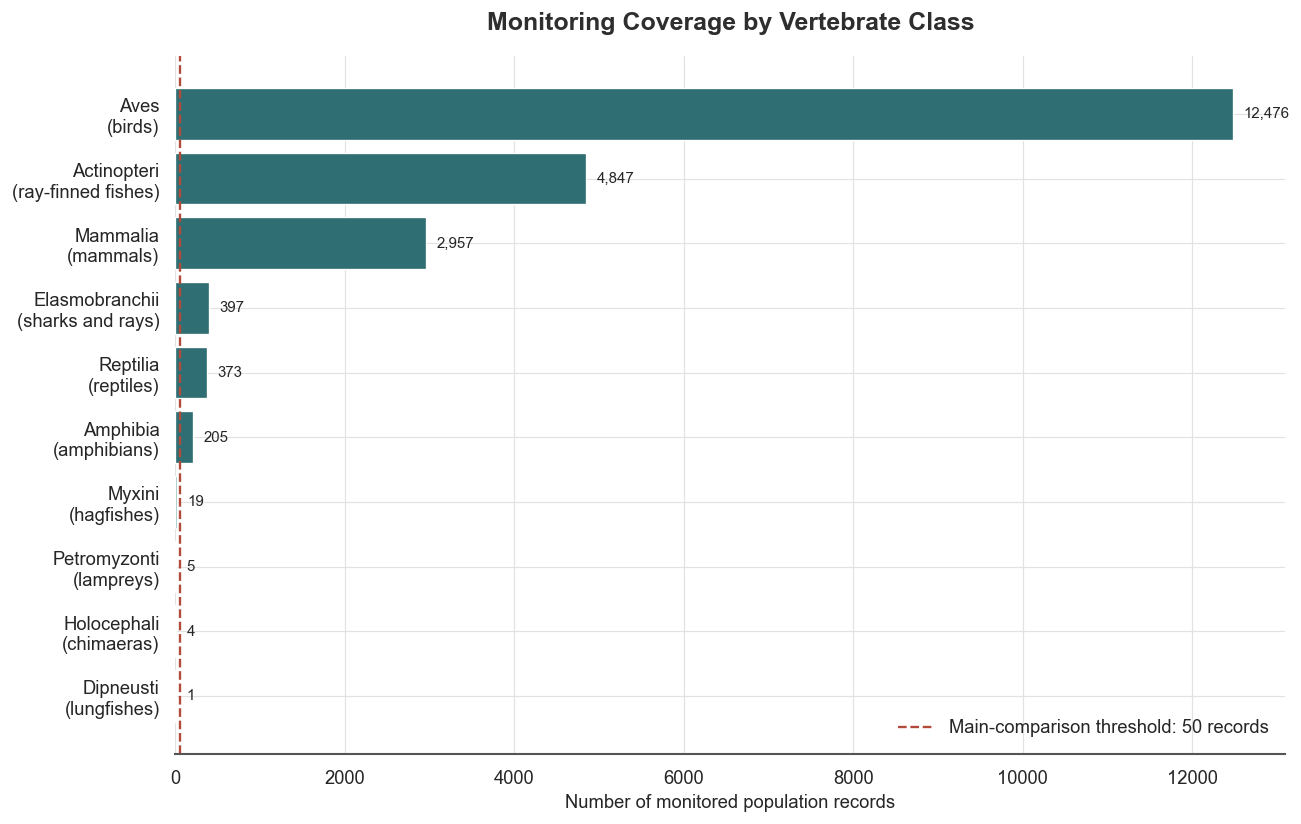

In [76]:
# Prepare class counts ordered from largest to smallest.
coverage_plot_data = class_counts.sort_values("Analyzed_Populations", ascending=True).copy()

# Mark whether each class is used in main comparative stakeholder charts.
coverage_plot_data["Coverage_Group"] = np.where(
    coverage_plot_data["Analyzed_Populations"] >= MIN_CLASS_POPULATIONS,
    "Shown in main comparisons",
    "Shown separately due to limited records"
)

# Create a color list that visually separates well-represented and underrepresented classes.
bar_colors = coverage_plot_data["Coverage_Group"].map({
    "Shown in main comparisons": COLORS["primary"],
    "Shown separately due to limited records": COLORS["primary_light"]
})

# Create a horizontal bar chart for monitoring coverage.
fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(
    coverage_plot_data["Class_Label"],
    coverage_plot_data["Analyzed_Populations"],
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8
)

# Add a vertical threshold line to make the visualization rule transparent.
ax.axvline(
    MIN_CLASS_POPULATIONS,
    color=COLORS["risk"],
    linestyle="--",
    linewidth=1.4,
    label=f"Main-comparison threshold: {MIN_CLASS_POPULATIONS} records"
)

# Add readable count labels at the end of each bar.
for i, value in enumerate(coverage_plot_data["Analyzed_Populations"]):
    ax.text(value + max(coverage_plot_data["Analyzed_Populations"]) * 0.01, i, f"{value:,}", va="center", fontsize=9)

# Format labels and title.
add_title(
    ax,
    "Monitoring Coverage by Vertebrate Class",
    
)
ax.set_xlabel("Number of monitored population records")
ax.set_ylabel("")
ax.legend(frameon=False, loc="lower right")
sns.despine(ax=ax, left=True, bottom=False)

plt.tight_layout()
save_figure(fig, "04_01_monitoring_coverage_by_class.png")
plt.show()

# Figure 2. Population trend distribution for well-represented classes

This is the main stakeholder-facing comparison of population trends by vertebrate class.

Only classes with sufficient monitoring coverage are shown, while small classes are kept for the separate coverage figure.

**README placement:** use this in the Key Findings section under “Declines are unevenly distributed across vertebrate groups”.

Saved: /Users/chintamany/Documents/living-planet-index-project/outputs/stakeholder_figures/04_02_population_trends_well_represented_classes.png


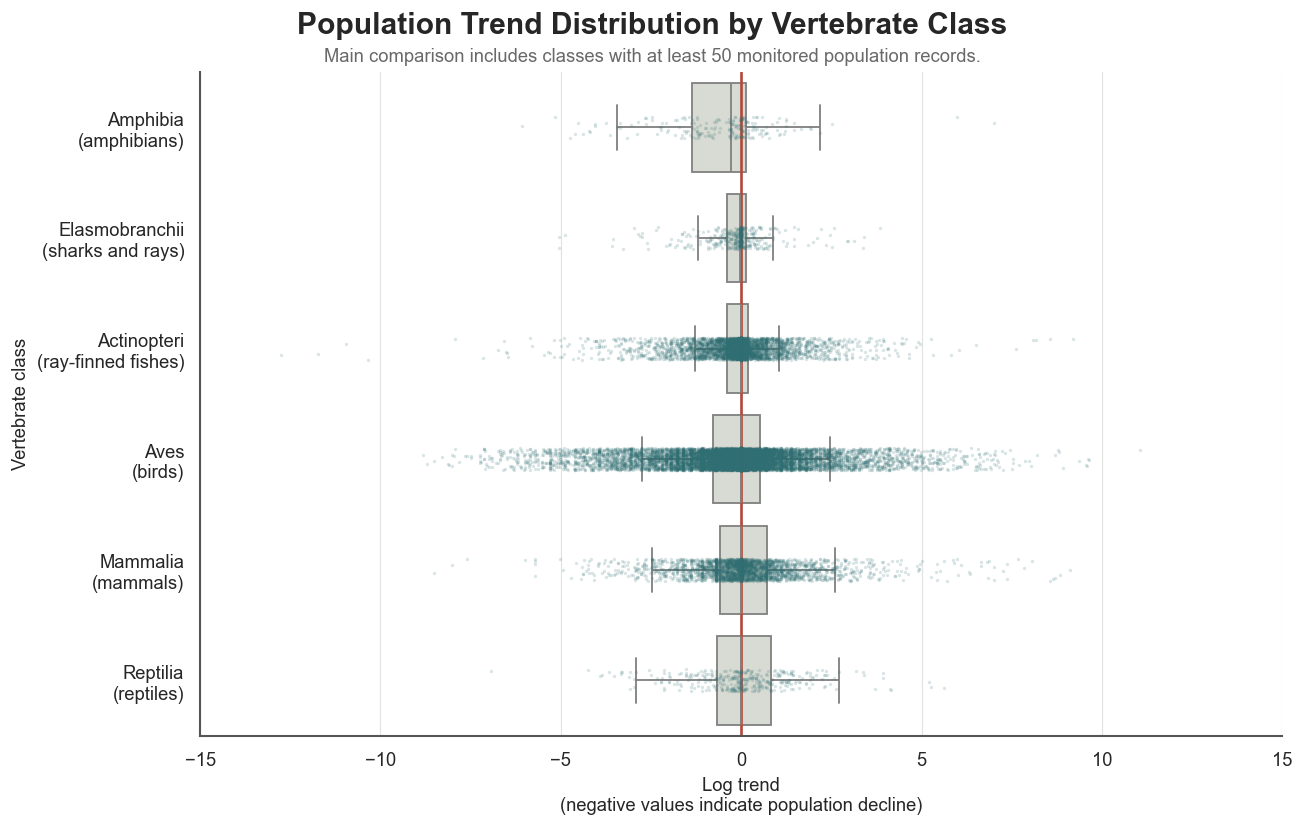

In [77]:
# Order well-represented classes by median log trend so the figure tells a clear story.
class_order = (
    main_class_data
    .groupby("Class_Label", observed=True)["Log_Trend"]
    .median()
    .sort_values()
    .index
)

# Create a boxplot with overlaid individual population records.
fig, ax = plt.subplots(figsize=(11, 7))
sns.boxplot(
    data=main_class_data,
    y="Class_Label",
    x="Log_Trend",
    order=class_order,
    color=COLORS["neutral"],
    fliersize=0,
    linewidth=1.1,
    ax=ax
)
sns.stripplot(
    data=main_class_data,
    y="Class_Label",
    x="Log_Trend",
    order=class_order,
    color=COLORS["primary"],
    alpha=0.18,
    size=2,
    ax=ax
)

# Add a vertical zero line: values left of this line indicate decline.
ax.axvline(0, color=COLORS["risk"], linewidth=1.6)

# Format labels and title.
fig.suptitle(
    "Population Trend Distribution by Vertebrate Class",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,           # horizontal center
    0.92,          # vertical position
    f"Main comparison includes classes with at least {MIN_CLASS_POPULATIONS} monitored population records.",
    ha="center",   # center align
    fontsize=11,
    color="dimgray"
)

plt.subplots_adjust(top=0.20)

ax.set_xlabel("Log trend\n(negative values indicate population decline)")
ax.set_ylabel("Vertebrate class")
ax.set_xlim(-15, 15)
sns.despine(ax=ax, left=False, bottom=False)

plt.tight_layout()
save_figure(fig, "04_02_population_trends_well_represented_classes.png")
plt.show()

# Figure 3. Underrepresented vertebrate classes

This figure communicates an important data-quality point: some vertebrate groups are present in the dataset but have too few monitored population records for strong visual comparison.

These groups are not ignored. They are shown separately to avoid overstating statistical confidence.

**README placement:** use this after the main class-trend figure, under a short subsection called “Important data caveat: some groups are rarely monitored”.

Saved: /Users/chintamany/Documents/living-planet-index-project/outputs/stakeholder_figures/04_03_underrepresented_vertebrate_classes.png


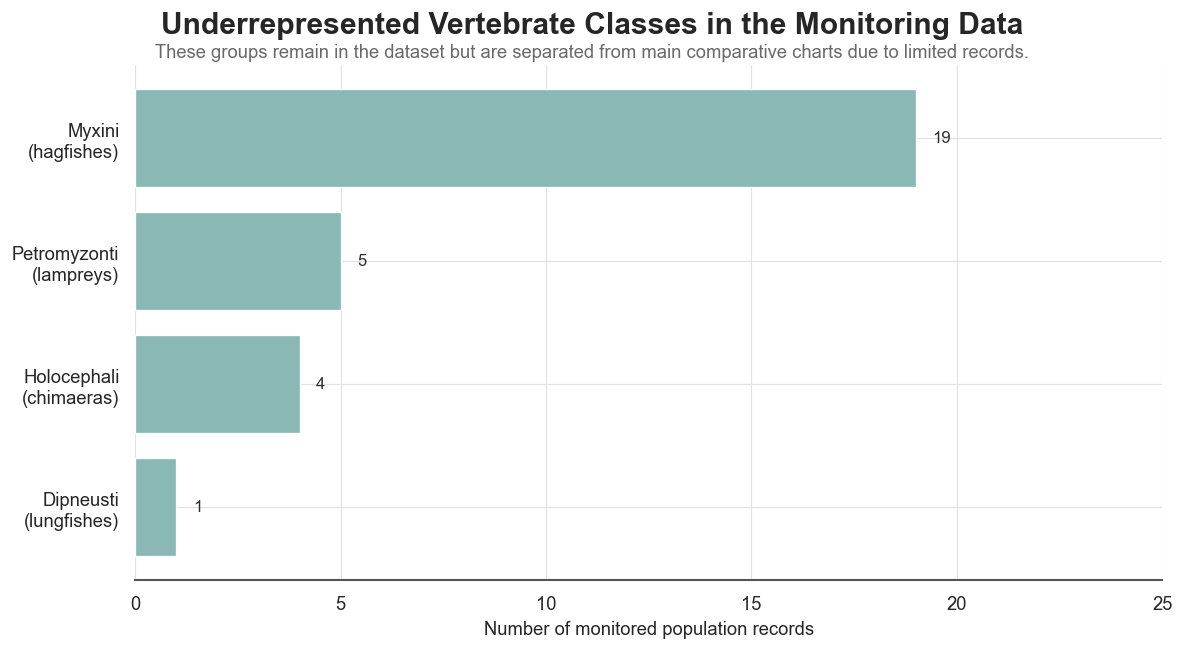

In [78]:
# Prepare a compact summary of underrepresented classes.
underrepresented_summary = (
    class_counts[class_counts["Class"].isin(underrepresented_classes)]
    .sort_values("Analyzed_Populations", ascending=True)
    .copy()
)

# Create a horizontal bar chart for underrepresented groups.
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(
    underrepresented_summary["Class_Label"],
    underrepresented_summary["Analyzed_Populations"],
    color=COLORS["primary_light"],
    edgecolor="white",
    linewidth=0.8
)

# Add count labels to make small sample sizes explicit.
for i, value in enumerate(underrepresented_summary["Analyzed_Populations"]):
    ax.text(value + 0.4, i, f"{value}", va="center", fontsize=10, color=COLORS["text"])

# Format labels and title.
fig.suptitle(
    "Underrepresented Vertebrate Classes in the Monitoring Data",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,           # horizontal center
    0.91,          # vertical position
    "These groups remain in the dataset but are separated from main comparative charts due to limited records.",
    ha="center",   # center align
    fontsize=11,
    color="dimgray"
)



ax.set_xlabel("Number of monitored population records")
ax.set_ylabel("")
ax.set_xlim(0, 25)
sns.despine(ax=ax, left=True, bottom=False)

plt.tight_layout()
save_figure(fig, "04_03_underrepresented_vertebrate_classes.png")
plt.show()

# Figure 4. Risk category distribution

This figure explains how many monitored populations fall into each risk category.

**README placement:** use this in the Key Findings section under “A substantial share of monitored populations is declining”.

Saved: /Users/chintamany/Documents/living-planet-index-project/outputs/stakeholder_figures/04_04_risk_category_distribution.png


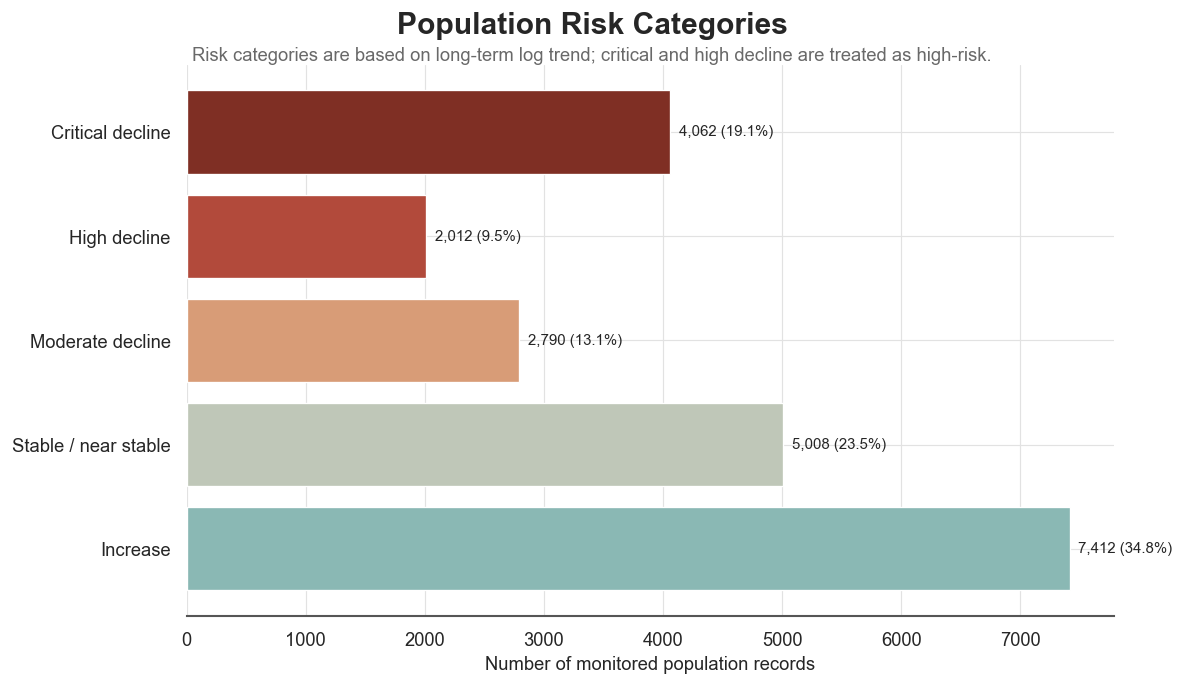

In [79]:
# Define the consistent risk order used throughout the project.
risk_order = [
    "Critical decline",
    "High decline",
    "Moderate decline",
    "Stable / near stable",
    "Increase"
]

# Count population records per risk category.
risk_counts = (
    trend_data["Risk_Category"]
    .value_counts()
    .reindex(risk_order)
    .reset_index()
)
risk_counts.columns = ["Risk_Category", "Analyzed_Populations"]

# Add percentage values for labels.
risk_counts["Share"] = risk_counts["Analyzed_Populations"] / risk_counts["Analyzed_Populations"].sum()

# Use a restrained color gradient that highlights decline categories.
risk_colors = [COLORS["risk_dark"], COLORS["risk"], "#D89C77", "#BFC7B8", COLORS["primary_light"]]

# Create a horizontal bar chart for risk categories.
fig, ax = plt.subplots(figsize=(10, 5.8))
ax.barh(
    risk_counts["Risk_Category"][::-1],
    risk_counts["Analyzed_Populations"][::-1],
    color=risk_colors[::-1],
    edgecolor="white",
    linewidth=0.8
)

# Add counts and percentages beside each bar.
for i, row in enumerate(risk_counts.iloc[::-1].itertuples(index=False)):
    label = f"{row.Analyzed_Populations:,} ({row.Share:.1%})"
    ax.text(row.Analyzed_Populations + risk_counts["Analyzed_Populations"].max() * 0.01, i, label, va="center", fontsize=9)

# Format labels and title.
fig.suptitle(
    "Population Risk Categories",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,           # horizontal center
    0.91,          # vertical position
    "Risk categories are based on long-term log trend; critical and high decline are treated as high-risk.",
    ha="center",   # center align
    fontsize=11,
    color="dimgray"
)

ax.set_xlabel("Number of monitored population records")
ax.set_ylabel("")
sns.despine(ax=ax, left=True, bottom=False)

plt.tight_layout()
save_figure(fig, "04_04_risk_category_distribution.png")
plt.show()

# Figure 5. High-risk share by region

This figure translates the risk classification into a simple regional comparison.

**README placement:** use this in the Key Findings section under “Biodiversity risk is geographically uneven”.

Saved: /Users/chintamany/Documents/living-planet-index-project/outputs/stakeholder_figures/04_05_high_risk_share_by_region.png


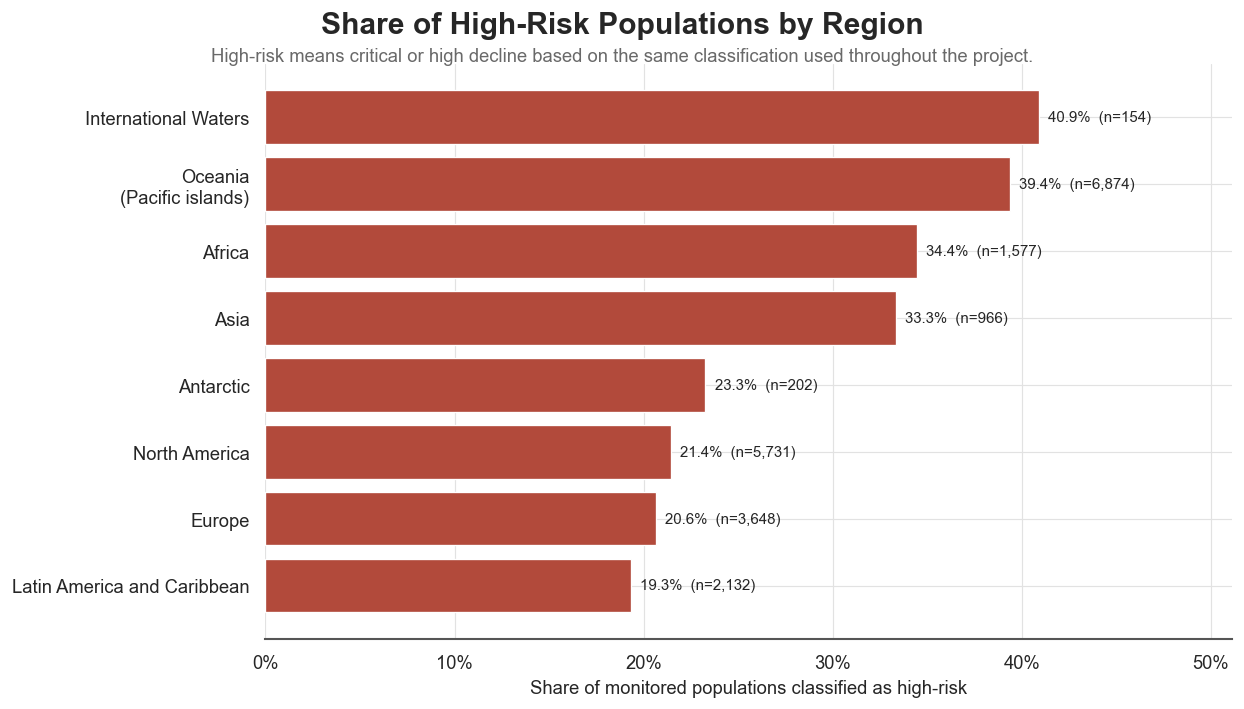

In [80]:
# Summarize total and high-risk population records by region.
region_risk = (
    trend_data
    .groupby(["Region", "Region_Label"], observed=True)
    .agg(
        Population_Records=("ID", "count"),
        High_Risk_Records=("High_Risk", "sum")
    )
    .reset_index()
)

# Calculate the share of high-risk populations for each region.
region_risk["High_Risk_Share"] = region_risk["High_Risk_Records"] / region_risk["Population_Records"]
region_risk = region_risk.sort_values("High_Risk_Share", ascending=True)

# Create a horizontal bar chart of high-risk share by region.
fig, ax = plt.subplots(figsize=(10.5, 6))
ax.barh(
    region_risk["Region_Label"],
    region_risk["High_Risk_Share"],
    color=COLORS["risk"],
    edgecolor="white",
    linewidth=0.8
)

# Add percentage and sample size labels.
for i, row in enumerate(region_risk.itertuples(index=False)):
    label = f"{row.High_Risk_Share:.1%}  (n={row.Population_Records:,})"
    ax.text(row.High_Risk_Share + 0.005, i, label, va="center", fontsize=9)

# Format labels and title.
fig.suptitle(
    "Share of High-Risk Populations by Region",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,           # horizontal center
    0.91,          # vertical position
    "High-risk means critical or high decline based on the same classification used throughout the project.",
    ha="center",   # center align
    fontsize=11,
    color="dimgray"
)


ax.set_xlabel("Share of monitored populations classified as high-risk")
ax.set_ylabel("")
ax.set_xlim(0, min(1, region_risk["High_Risk_Share"].max() * 1.25))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
sns.despine(ax=ax, left=True, bottom=False)

plt.tight_layout()
save_figure(fig, "04_05_high_risk_share_by_region.png")
plt.show()

# Figure 6. Region × class high-risk heatmap

This figure shows that biodiversity risk is not only regional or taxonomic. It often emerges from specific combinations of region and vertebrate group.

Only well-represented vertebrate classes are included in this communication figure.

**README placement:** use this as one of the strongest summary visuals in the Key Findings section.

Saved: /Users/chintamany/Documents/living-planet-index-project/outputs/stakeholder_figures/04_06_region_class_high_risk_heatmap.png


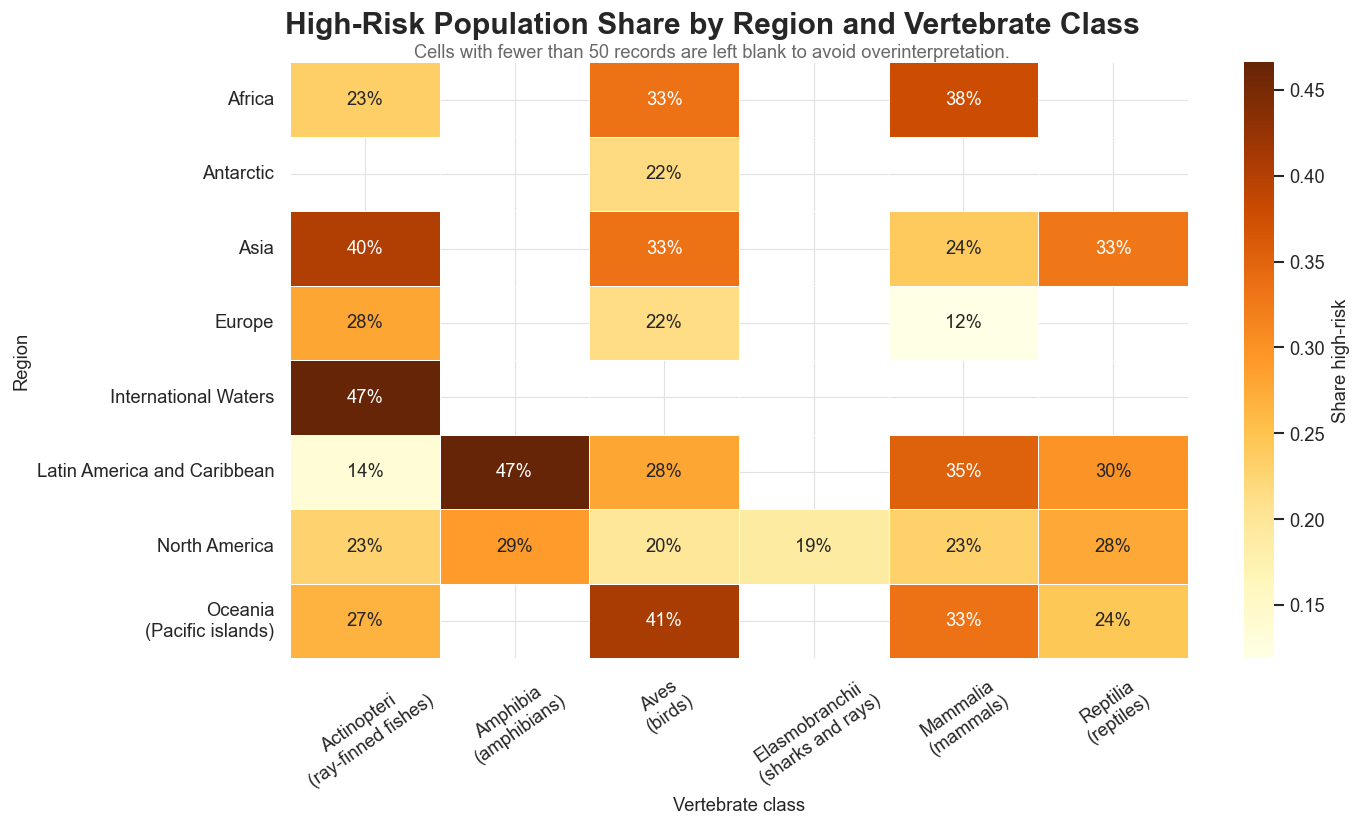

In [81]:
# Use only well-represented classes for the stakeholder heatmap.
heatmap_data = main_class_data.copy()

# Calculate high-risk share for each region-class combination.
region_class_risk = (
    heatmap_data
    .groupby(["Region_Label", "Class_Label"], observed=True)
    .agg(
        Analyzed_Populations=("ID", "count"),
        High_Risk_Records=("High_Risk", "sum")
    )
    .reset_index()
)
region_class_risk["High_Risk_Share"] = (
    region_class_risk["High_Risk_Records"] / region_class_risk["Analyzed_Populations"]
)

# Avoid unstable cells with very few records.
region_class_risk.loc[
    region_class_risk["Analyzed_Populations"] < MIN_CLASS_POPULATIONS,
    "High_Risk_Share"
] = np.nan

# Convert the summary into a matrix for heatmap plotting.
heatmap_matrix = region_class_risk.pivot(
    index="Region_Label",
    columns="Class_Label",
    values="High_Risk_Share"
)

# Create the heatmap.
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    heatmap_matrix,
    cmap="YlOrBr",
    annot=True,
    fmt=".0%",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Share high-risk"},
    ax=ax
)

# Format labels and title.
fig.suptitle(
    "High-Risk Population Share by Region and Vertebrate Class",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,           # horizontal center
    0.925,          # vertical position
    f"Cells with fewer than {MIN_CLASS_POPULATIONS} records are left blank to avoid overinterpretation.",
    ha="center",   # center align
    fontsize=11,
    color="dimgray"
)

plt.subplots_adjust(top=0.70)

ax.set_xlabel("Vertebrate class")
ax.set_ylabel("Region")
ax.tick_params(axis="x", labelrotation=35)
ax.tick_params(axis="y", labelrotation=0)

plt.tight_layout()
save_figure(fig, "04_06_region_class_high_risk_heatmap.png")
plt.show()

# Figure 7. Global distribution of monitored populations

This map shows where the Living Planet Database contains monitoring records. It is a coverage map, not a risk map.

**README placement:** use this in the Dataset / Data Coverage section.

Saved: /Users/chintamany/Documents/living-planet-index-project/outputs/stakeholder_figures/04_07_global_monitoring_coverage_map.png


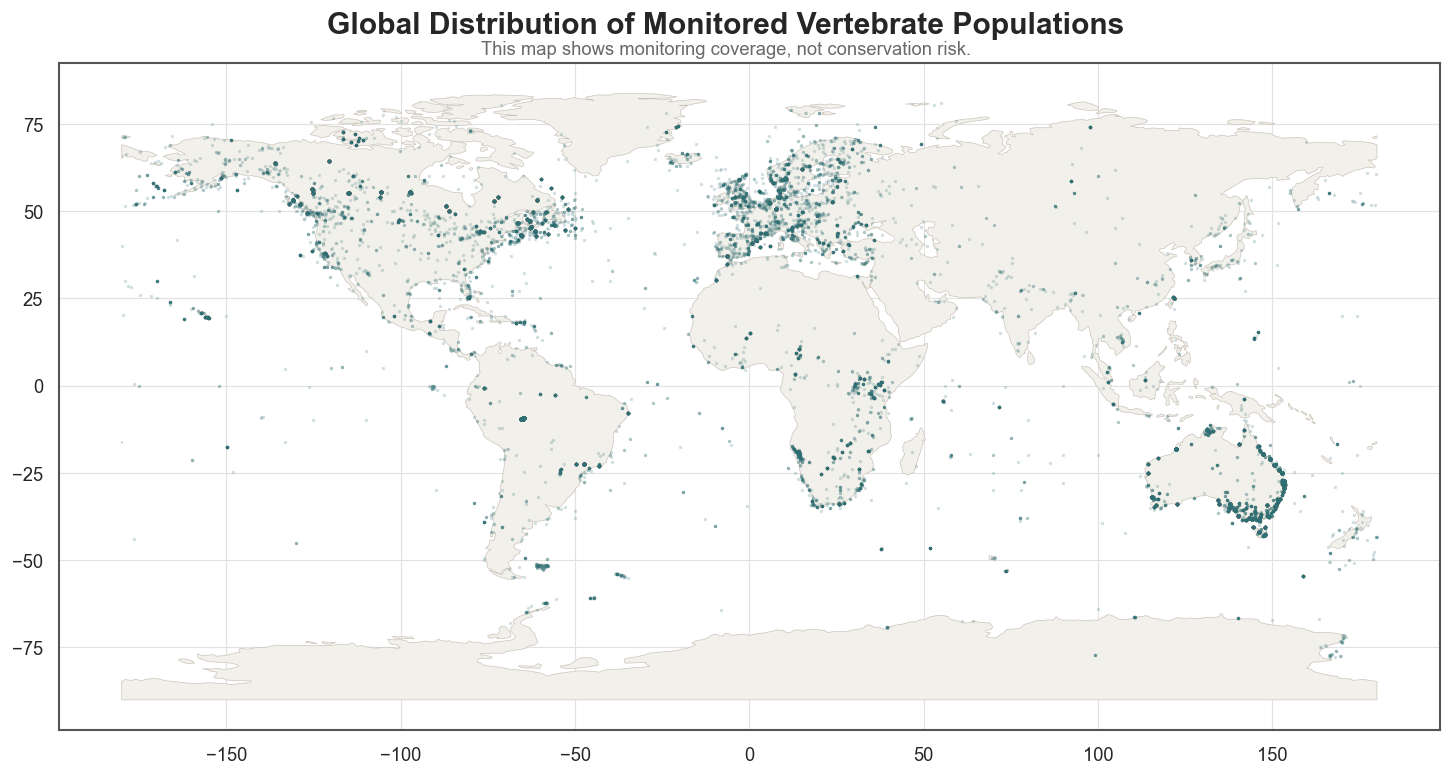

In [82]:
# Create a world map showing all monitored population locations.
fig, ax = plt.subplots(figsize=(13, 6.5))

# Draw the world map background if available.
if world is not None:
    world.plot(ax=ax, color=COLORS["land"], edgecolor=COLORS["land_edge"], linewidth=0.4, zorder=1)

# Plot all monitored populations as small transparent points.
ax.scatter(
    trend_data["Longitude"],
    trend_data["Latitude"],
    s=4,
    alpha=0.22,
    color=COLORS["primary"],
    linewidths=0,
    zorder=2
)

# Format the map for stakeholder communication.
fig.suptitle(
    "Global Distribution of Monitored Vertebrate Populations",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,           # horizontal center
    0.925,          # vertical position
    "This map shows monitoring coverage, not conservation risk.",
    ha="center",   # center align
    fontsize=11,
    color="dimgray"
)


plt.tight_layout()
save_figure(fig, "04_07_global_monitoring_coverage_map.png")
plt.show()

# Figure 8. Global distribution of high-risk populations

This map shows where populations classified as critical or high decline are located.

**README placement:** use this in the Key Findings section under “High-risk populations are geographically clustered”.

Saved: /Users/chintamany/Documents/living-planet-index-project/outputs/stakeholder_figures/04_08_global_high_risk_population_map.png


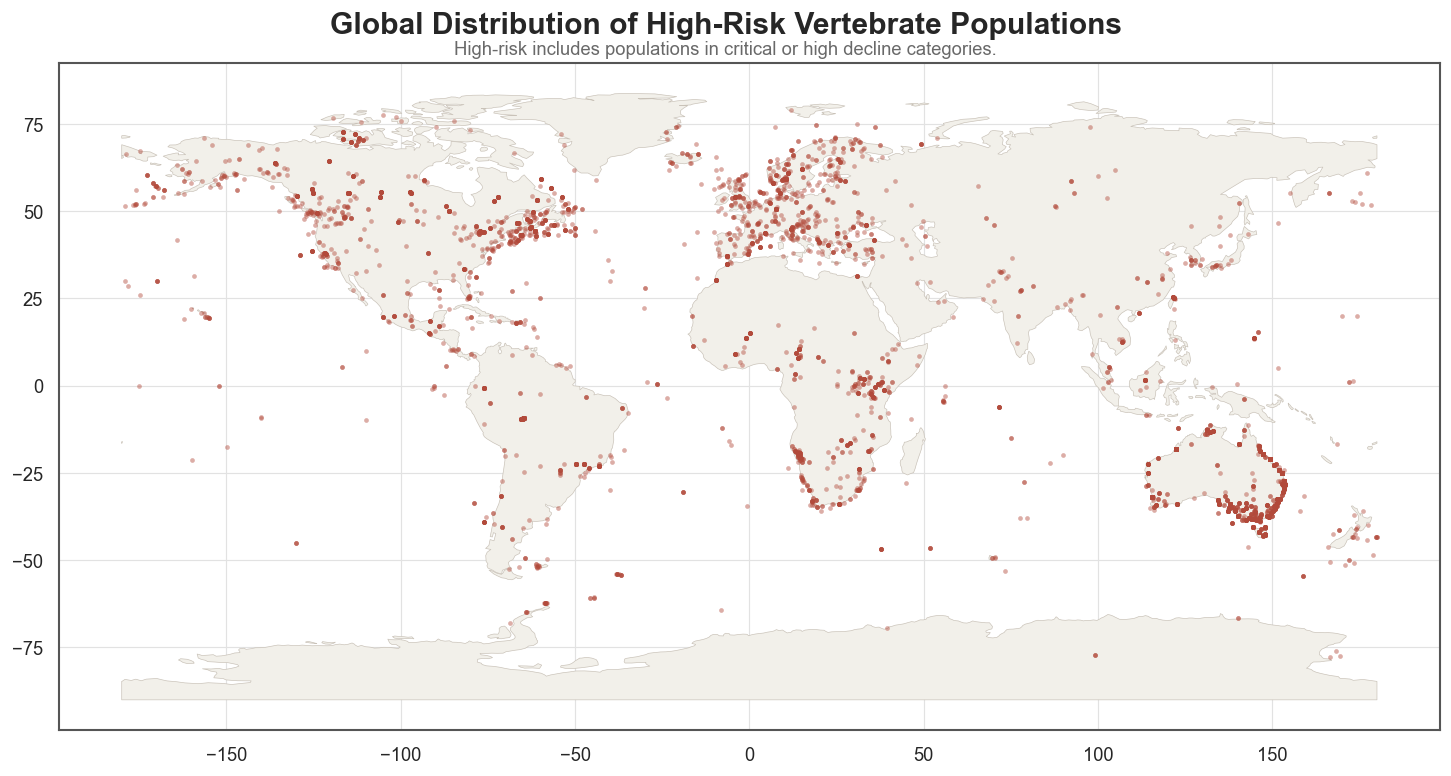

In [83]:
# Keep only populations classified as high-risk.
high_risk_data = trend_data[trend_data["High_Risk"]].copy()

# Create a world map showing high-risk population locations.
fig, ax = plt.subplots(figsize=(13, 6.5))

# Draw the world map background if available.
if world is not None:
    world.plot(ax=ax, color=COLORS["land"], edgecolor=COLORS["land_edge"], linewidth=0.4, zorder=1)

# Plot high-risk populations as red points.
ax.scatter(
    high_risk_data["Longitude"],
    high_risk_data["Latitude"],
    s=8,
    alpha=0.45,
    color=COLORS["risk"],
    linewidths=0,
    zorder=2
)

# Format the map for stakeholder communication.
fig.suptitle(
    "Global Distribution of High-Risk Vertebrate Populations",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,           # horizontal center
    0.925,          # vertical position
    "High-risk includes populations in critical or high decline categories.",
    ha="center",   # center align
    fontsize=11,
    color="dimgray"
)



plt.tight_layout()
save_figure(fig, "04_08_global_high_risk_population_map.png")
plt.show()

# Figure 9. Exploratory hotspot grid

This map aggregates monitored populations into 10-degree grid cells. Bubble size represents monitoring volume, while color represents the share of high-risk populations.

It is exploratory and should be interpreted as a broad screening tool rather than a formal hotspot model.

**README placement:** use this as the final visual in the Key Findings section.

Saved: /Users/chintamany/Documents/living-planet-index-project/outputs/stakeholder_figures/04_09_exploratory_high_risk_hotspot_grid.png


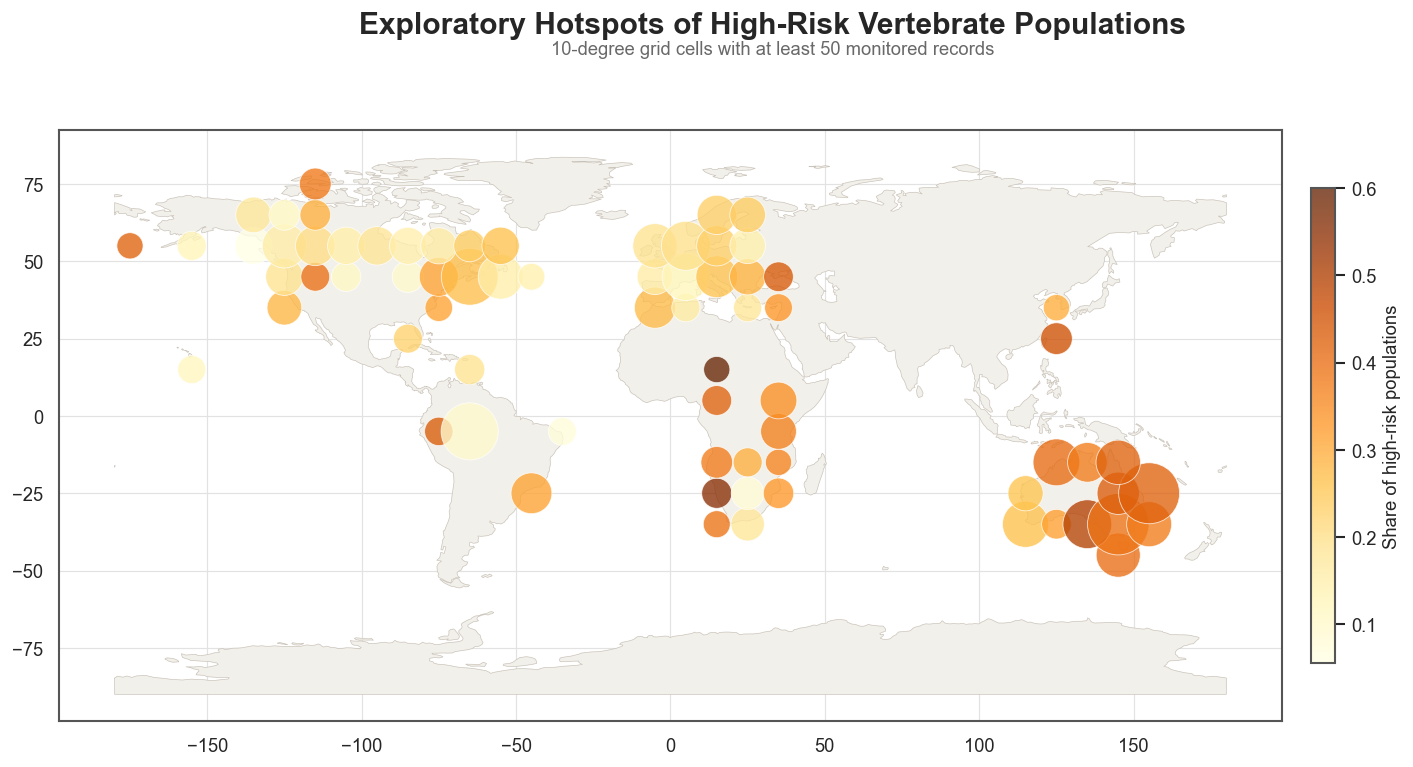

In [84]:
# Create 10-degree grid bins for latitude and longitude.
grid_data = trend_data.dropna(subset=["Latitude", "Longitude", "High_Risk"]).copy()
grid_data["Lat_Bin"] = (np.floor(grid_data["Latitude"] / 10) * 10) + 5
grid_data["Lon_Bin"] = (np.floor(grid_data["Longitude"] / 10) * 10) + 5

# Summarize total and high-risk records in each grid cell.
grid_summary = (
    grid_data
    .groupby(["Lat_Bin", "Lon_Bin"], observed=True)
    .agg(
        Analyzed_Populations=("ID", "count"),
        High_Risk_Records=("High_Risk", "sum")
    )
    .reset_index()
)

# Calculate the high-risk share within each grid cell.
grid_summary["High_Risk_Share"] = grid_summary["High_Risk_Records"] / grid_summary["Analyzed_Populations"]

# Keep only grid cells with enough monitoring records to make the share interpretable.
grid_summary_filtered = grid_summary[grid_summary["Analyzed_Populations"] >= MIN_CLASS_POPULATIONS].copy()

# Create an exploratory hotspot map.
fig, ax = plt.subplots(figsize=(13, 6.5))

# Draw the world map background if available.
if world is not None:
    world.plot(ax=ax, color=COLORS["land"], edgecolor=COLORS["land_edge"], linewidth=0.4, zorder=1)

# Plot grid cells as bubbles.
# Bubble size reflects the number of monitored population records.
# Bubble color reflects the share of high-risk populations.
scatter = ax.scatter(
    grid_summary_filtered["Lon_Bin"],
    grid_summary_filtered["Lat_Bin"],
    s=np.sqrt(grid_summary_filtered["Analyzed_Populations"]) * 35,
    c=grid_summary_filtered["High_Risk_Share"],
    cmap="YlOrBr",
    alpha=0.78,
    edgecolor="white",
    linewidth=0.5,
    zorder=2
)

# Add a colorbar explaining the high-risk share.
cbar = fig.colorbar(scatter, ax=ax, shrink=0.72, pad=0.02)
cbar.set_label("Share of high-risk populations")

# Format the map for stakeholder communication.
fig.suptitle(
    "Exploratory Hotspots of High-Risk Vertebrate Populations\n",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,           # horizontal center
    0.925,          # vertical position
    f"10-degree grid cells with at least {MIN_CLASS_POPULATIONS} monitored records",
    ha="center",   # center align
    fontsize=11,
    color="dimgray"
)



plt.tight_layout()
save_figure(fig, "04_09_exploratory_high_risk_hotspot_grid.png")
plt.show()

## 7. Export stakeholder summary tables

These tables make the figure logic transparent and can be referenced in the README or presentation notes.

In [85]:
# Save class coverage summary.
class_counts.to_csv(FIGURES_DIR / "04_table_class_monitoring_coverage.csv", index=False)

# Save regional high-risk summary.
region_risk.to_csv(FIGURES_DIR / "04_table_region_high_risk_share.csv", index=False)

# Save region-class high-risk summary.
region_class_risk.to_csv(FIGURES_DIR / "04_table_region_class_high_risk_share.csv", index=False)

# Save hotspot grid summary.
grid_summary_filtered.to_csv(FIGURES_DIR / "04_table_exploratory_hotspot_grid.csv", index=False)

print("Saved stakeholder summary tables to:", FIGURES_DIR)

Saved stakeholder summary tables to: /Users/chintamany/Documents/living-planet-index-project/outputs/stakeholder_figures


## 8. Final note for interpretation

The figures in this notebook are designed for communication, not to replace the scientific workflow.

The main analysis keeps all available population records. For public-facing comparative visuals, very small vertebrate classes are separated to prevent misleading interpretation.